# EfficientNet-B0: Augmentation + Weighted Random Sampler + Dropout

## Motivation
L1/L2 penalties in the previous notebook closed the train-val gap but did not improve val F2 — they make the model more conservative (hurts recall) without addressing the real problem: distribution shift after fixing the lesion-ID leakage.

This notebook targets the same model (EfficientNet-B0, unfreeze last 3 blocks) with three complementary techniques:
- **Augmentation** — `get_augmented_train_transforms()` (ColorJitter, RandomVerticalFlip, RandomAffine, stronger rotation)
- **WeightedRandomSampler (WRS)** — oversamples melanoma (877 / 7991 ≈ 11%) so each epoch sees a balanced class distribution
- **Dropout** — `nn.Dropout(0.4)` in the classifier head, more targeted than L1/L2 for preventing memorisation

## Runs
| Run | Augmentation | WRS | Dropout | L1 | L2 | Purpose |
|-----|---|---|---|---|---|---|
| Baseline | No | No | 0.0 | 0 | 0 | Reproduce penalty-notebook baseline |
| Augmented | Yes | No | 0.0 | 0 | 0 | Augmentation only |
| Aug+WRS | Yes | Yes | 0.0 | 0 | 0 | Augmentation + oversampling |
| Aug+WRS+Dropout | Yes | Yes | 0.4 | 0 | 0 | Full combined (no penalty) |
| Aug+WRS+Drop+L1+L2 | Yes | Yes | 0.4 | 1e-3 | 1e-3 | Full combined + penalty to close gap |

In [15]:
import sys
import os
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import fbeta_score, recall_score, precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.data.dataset import HAM10000Dataset
from src.data.transform import get_augmented_train_transforms, get_train_transforms, get_eval_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [16]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [17]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [18]:
TRAIN_CSV      = 'data_new/splits/train.csv'
VAL_CSV        = 'data_new/splits/val.csv'
TEST_CSV       = 'data_new/splits/test.csv'
IMAGE_DIR      = 'data_new/images/train'
TEST_IMAGE_DIR = 'data_new/images/test'
BATCH_SIZE     = 32
IMAGE_SIZE     = 224
NUM_WORKERS    = 0

train_df = pd.read_csv(TRAIN_CSV)
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print(f'Train samples: {len(train_df)} | Melanoma: {num_melanoma} | Nevus: {num_nevus}')
print(f'Positive weight: {pos_weight.item():.4f}')

# Val and test loaders never change — build once
eval_transform = get_eval_transforms(image_size=IMAGE_SIZE)

val_dataset  = HAM10000Dataset(csv_path=VAL_CSV,  image_dir=IMAGE_DIR,      transform=eval_transform)
test_dataset = HAM10000Dataset(csv_path=TEST_CSV, image_dir=TEST_IMAGE_DIR, transform=eval_transform)

val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train samples: 7991 | Melanoma: 877 | Nevus: 7114
Positive weight: 8.1117
Val batches: 64 | Test batches: 48


In [19]:
def make_train_loader(augment: bool, weighted: bool):
    """Build a train DataLoader with optional augmentation and WeightedRandomSampler."""
    transform = get_augmented_train_transforms(image_size=IMAGE_SIZE) if augment else get_train_transforms(image_size=IMAGE_SIZE)
    dataset   = HAM10000Dataset(csv_path=TRAIN_CSV, image_dir=IMAGE_DIR, transform=transform)

    if weighted:
        labels         = train_df['label'].values
        class_counts   = np.bincount(labels)                     # [n_nevus, n_melanoma]
        class_weights  = 1.0 / class_counts                      # inverse-frequency weights
        sample_weights = torch.tensor(class_weights[labels], dtype=torch.float32)
        sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
    else:
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

    return loader

## Experiment Runs

In [20]:
run_configs = [
    {'label': 'Baseline',            'augment': False, 'weighted': False, 'dropout': 0.0, 'l1': 0.0,  'l2': 0.0},
    {'label': 'Augmented',           'augment': True,  'weighted': False, 'dropout': 0.0, 'l1': 0.0,  'l2': 0.0},
    {'label': 'Aug+WRS+Dropout',     'augment': True,  'weighted': True,  'dropout': 0.4, 'l1': 0.0,  'l2': 0.0},
    {'label': 'Aug+WRS+Drop+L1+L2', 'augment': True,  'weighted': True,  'dropout': 0.4, 'l1': 1e-3, 'l2': 1e-3},
]

NUM_EPOCHS = 15
all_results = {}

In [21]:
for cfg in run_configs:
    run_label = cfg['label']
    print(f"\n{'='*60}")
    print(f"Run: {run_label} | augment={cfg['augment']} | weighted={cfg['weighted']} | dropout={cfg['dropout']} | l1={cfg['l1']} | l2={cfg['l2']}")
    print('='*60)

    set_seed(42)

    train_loader = make_train_loader(augment=cfg['augment'], weighted=cfg['weighted'])

    model = get_efficientnet(
        variant='b0',
        num_classes=1,
        unfreeze_last_n_blocks=3,
        dropout=cfg['dropout'],
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

    history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
    best_val_f2 = 0.0
    best_state  = None

    for epoch in range(NUM_EPOCHS):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=cfg['l1'], l2_lambda=cfg['l2'])
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_f2'].append(train_metrics['f2'])
        history['val_f2'].append(val_metrics['f2'])

        scheduler.step(val_metrics['f2'])
        current_lr = optimizer.param_groups[0]['lr']

        print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

        if val_metrics['f2'] > best_val_f2:
            best_val_f2 = val_metrics['f2']
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'    -> New best val F2: {best_val_f2:.4f}')

    all_results[run_label] = {
        'history':      history,
        'best_val_f2':  best_val_f2,
        'best_state':   best_state,
        'cfg':          cfg,
    }
    print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')


Run: Baseline | augment=False | weighted=False | dropout=0.0 | l1=0.0 | l2=0.0


  Epoch [1/15] | Train Loss: 0.9084, F2: 0.5521 | Val Loss: 0.8232, F2: 0.5911 | LR: 1.00e-04
    -> New best val F2: 0.5911


  Epoch [2/15] | Train Loss: 0.6885, F2: 0.6518 | Val Loss: 0.7861, F2: 0.6188 | LR: 1.00e-04
    -> New best val F2: 0.6188


  Epoch [3/15] | Train Loss: 0.5911, F2: 0.6949 | Val Loss: 0.8116, F2: 0.6299 | LR: 1.00e-04
    -> New best val F2: 0.6299


  Epoch [4/15] | Train Loss: 0.4901, F2: 0.7462 | Val Loss: 0.9104, F2: 0.6211 | LR: 1.00e-04


...

  Epoch [11/15] | Train Loss: 0.8206, F2: 0.9061 | Val Loss: 1.0671, F2: 0.5816 | LR: 1.00e-04
    -> New best val F2: 0.5816


  Epoch [12/15] | Train Loss: 0.8331, F2: 0.9069 | Val Loss: 0.9630, F2: 0.6028 | LR: 1.00e-04
    -> New best val F2: 0.6028


  Epoch [13/15] | Train Loss: 0.8157, F2: 0.9046 | Val Loss: 1.3114, F2: 0.5607 | LR: 1.00e-04


  Epoch [14/15] | Train Loss: 0.8089, F2: 0.9090 | Val Loss: 1.3378, F2: 0.5705 | LR: 1.00e-04


  Epoch [15/15] | Train Loss: 0.7897, F2: 0.9125 | Val Loss: 1.4801, F2: 0.5676 | LR: 1.00e-04
Best val F2 for Aug+WRS+Drop+L1+L2: 0.6028


In [29]:
# Additional runs: Augmentation + L1/L2 penalty combinations
extra_configs = [
    {'label': 'Aug+L1',    'augment': True, 'weighted': False, 'dropout': 0.0, 'l1': 1e-3, 'l2': 0.0},
    {'label': 'Aug+L2',    'augment': True, 'weighted': False, 'dropout': 0.0, 'l1': 0.0,  'l2': 1e-3},
    {'label': 'Aug+L1+L2', 'augment': True, 'weighted': False, 'dropout': 0.0, 'l1': 1e-3, 'l2': 1e-3},
]

for cfg in extra_configs:
    run_label = cfg['label']
    print(f"\n{'='*60}")
    print(f"Run: {run_label} | augment={cfg['augment']} | weighted={cfg['weighted']} | dropout={cfg['dropout']} | l1={cfg['l1']} | l2={cfg['l2']}")
    print('='*60)

    set_seed(42)

    train_loader = make_train_loader(augment=cfg['augment'], weighted=cfg['weighted'])

    model = get_efficientnet(
        variant='b0',
        num_classes=1,
        unfreeze_last_n_blocks=3,
        dropout=cfg['dropout'],
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

    history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
    best_val_f2 = 0.0
    best_state  = None

    for epoch in range(NUM_EPOCHS):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=cfg['l1'], l2_lambda=cfg['l2'])
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_f2'].append(train_metrics['f2'])
        history['val_f2'].append(val_metrics['f2'])

        scheduler.step(val_metrics['f2'])
        current_lr = optimizer.param_groups[0]['lr']

        print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

        if val_metrics['f2'] > best_val_f2:
            best_val_f2 = val_metrics['f2']
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'    -> New best val F2: {best_val_f2:.4f}')

    all_results[run_label] = {
        'history':      history,
        'best_val_f2':  best_val_f2,
        'best_state':   best_state,
        'cfg':          cfg,
    }
    print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')


Run: Aug+L1 | augment=True | weighted=False | dropout=0.0 | l1=0.001 | l2=0.0


  Epoch [1/15] | Train Loss: 1.0074, F2: 0.5127 | Val Loss: 0.8653, F2: 0.5784 | LR: 1.00e-04
    -> New best val F2: 0.5784


  Epoch [2/15] | Train Loss: 0.8461, F2: 0.5654 | Val Loss: 0.8096, F2: 0.6009 | LR: 1.00e-04
    -> New best val F2: 0.6009


  Epoch [3/15] | Train Loss: 0.8040, F2: 0.5963 | Val Loss: 0.8447, F2: 0.5630 | LR: 1.00e-04


  Epoch [4/15] | Train Loss: 0.7870, F2: 0.6010 | Val Loss: 0.8091, F2: 0.5874 | LR: 1.00e-04


...

  Epoch [11/15] | Train Loss: 0.7585, F2: 0.6098 | Val Loss: 0.8093, F2: 0.5990 | LR: 5.00e-05


  Epoch [12/15] | Train Loss: 0.7279, F2: 0.6328 | Val Loss: 0.7584, F2: 0.6073 | LR: 5.00e-05


  Epoch [13/15] | Train Loss: 0.7415, F2: 0.6268 | Val Loss: 0.7260, F2: 0.6373 | LR: 5.00e-05
    -> New best val F2: 0.6373


  Epoch [14/15] | Train Loss: 0.7107, F2: 0.6333 | Val Loss: 0.7922, F2: 0.6086 | LR: 5.00e-05


  Epoch [15/15] | Train Loss: 0.7252, F2: 0.6305 | Val Loss: 0.7295, F2: 0.6453 | LR: 5.00e-05
    -> New best val F2: 0.6453
Best val F2 for Aug+L1+L2: 0.6453


## Compare Overfitting: Train vs Val F2 Gap

In [30]:
print(f"{'Run':<20} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'Gap (T-V)':>9}")
print('-' * 78)
for run_label, result in all_results.items():
    h = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2   = h['val_f2'][-1]
    gap            = final_train_f2 - final_val_f2
    print(f"{run_label:<20} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>9.4f}")

Run                  | Best Val F2 | Final Train F2 | Final Val F2 | Gap (T-V)
------------------------------------------------------------------------------
Baseline             |      0.6487 |         0.9245 |       0.6340 |    0.2905
Augmented            |      0.6537 |         0.7132 |       0.6303 |    0.0830
Aug+WRS+Dropout      |      0.6480 |         0.9472 |       0.6285 |    0.3187
Aug+WRS+Drop+L1+L2   |      0.6028 |         0.9125 |       0.5676 |    0.3449
Aug+L1               |      0.6478 |         0.6434 |       0.6366 |    0.0067
Aug+L2               |      0.6477 |         0.7119 |       0.6187 |    0.0933
Aug+L1+L2            |      0.6453 |         0.6305 |       0.6453 |   -0.0147


## Compare Overfitting: Train vs Val Loss Gap

In [23]:
print(f"{'Run':<20} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print('-' * 70)
for run_label, result in all_results.items():
    h              = result['history']
    final_train    = h['train_loss'][-1]
    final_val      = h['val_loss'][-1]
    gap            = final_val - final_train
    print(f"{run_label:<20} | {final_train:>15.4f} | {final_val:>14.4f} | {gap:>14.4f}")

Run                  | Final Train Loss | Final Val Loss | Loss Gap (V-T)
----------------------------------------------------------------------
Baseline             |          0.1444 |         1.1401 |         0.9957
Augmented            |          0.5405 |         0.8732 |         0.3327
Aug+WRS+Dropout      |          0.4864 |         0.9597 |         0.4732
Aug+WRS+Drop+L1+L2   |          0.7897 |         1.4801 |         0.6904


## Compare Test Loss, Recall and F2 for All Runs

In [24]:
print(f"{'Run':<20} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test Prec':>10} | {'Test F2':>9} | {'Threshold':>9}")
print('-' * 80)

for run_label, result in all_results.items():
    cfg = result['cfg']
    eval_model = get_efficientnet(
        variant='b0',
        num_classes=1,
        unfreeze_last_n_blocks=3,
        dropout=cfg['dropout'],
    ).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Tune threshold on val set
    val_probs_run, val_labels_run = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = eval_model(images.to(device))
            probs   = torch.sigmoid(outputs).squeeze(1)
            val_probs_run.extend(probs.cpu().numpy())
            val_labels_run.extend(labels.numpy())

    thresholds  = np.arange(0.01, 0.90, 0.01)
    f2_scores   = [fbeta_score(val_labels_run, (np.array(val_probs_run) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_thresh = thresholds[np.argmax(f2_scores)]

    # Evaluate on test set
    running_loss   = 0.0
    total_samples  = 0
    all_labels_t   = []
    all_probs_t    = []

    with torch.no_grad():
        for images, labels in test_loader:
            images     = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs    = eval_model(images)
            loss       = criterion_eval(outputs, labels_dev)
            running_loss  += loss.item() * images.size(0)
            total_samples += images.size(0)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs_t.extend(probs.cpu().numpy())
            all_labels_t.extend(labels.numpy())

    test_loss  = running_loss / total_samples
    preds      = (np.array(all_probs_t) >= best_thresh).astype(int)
    test_f2    = fbeta_score(all_labels_t, preds, beta=2, pos_label=1, zero_division=0)
    test_rec   = recall_score(all_labels_t, preds, pos_label=1, zero_division=0)
    test_prec  = precision_score(all_labels_t, preds, pos_label=1, zero_division=0)

    all_results[run_label]['test_f2']     = test_f2
    all_results[run_label]['test_recall'] = test_rec
    all_results[run_label]['test_prec']   = test_prec
    all_results[run_label]['test_loss']   = test_loss
    all_results[run_label]['threshold']   = best_thresh

    print(f"{run_label:<20} | {test_loss:>9.4f} | {test_rec:>11.4f} | {test_prec:>10.4f} | {test_f2:>9.4f} | {best_thresh:>9.2f}")

Run                  | Test Loss | Test Recall |  Test Prec |   Test F2 | Threshold
--------------------------------------------------------------------------------
Baseline             |    0.9289 |      0.8129 |     0.3537 |    0.6453 |      0.39
Augmented            |    0.9003 |      0.8246 |     0.3256 |    0.6312 |      0.51
Aug+WRS+Dropout      |    0.9233 |      0.7953 |     0.3200 |    0.6132 |      0.56
Aug+WRS+Drop+L1+L2   |    1.0113 |      0.7544 |     0.3431 |    0.6085 |      0.86


## Training Curves

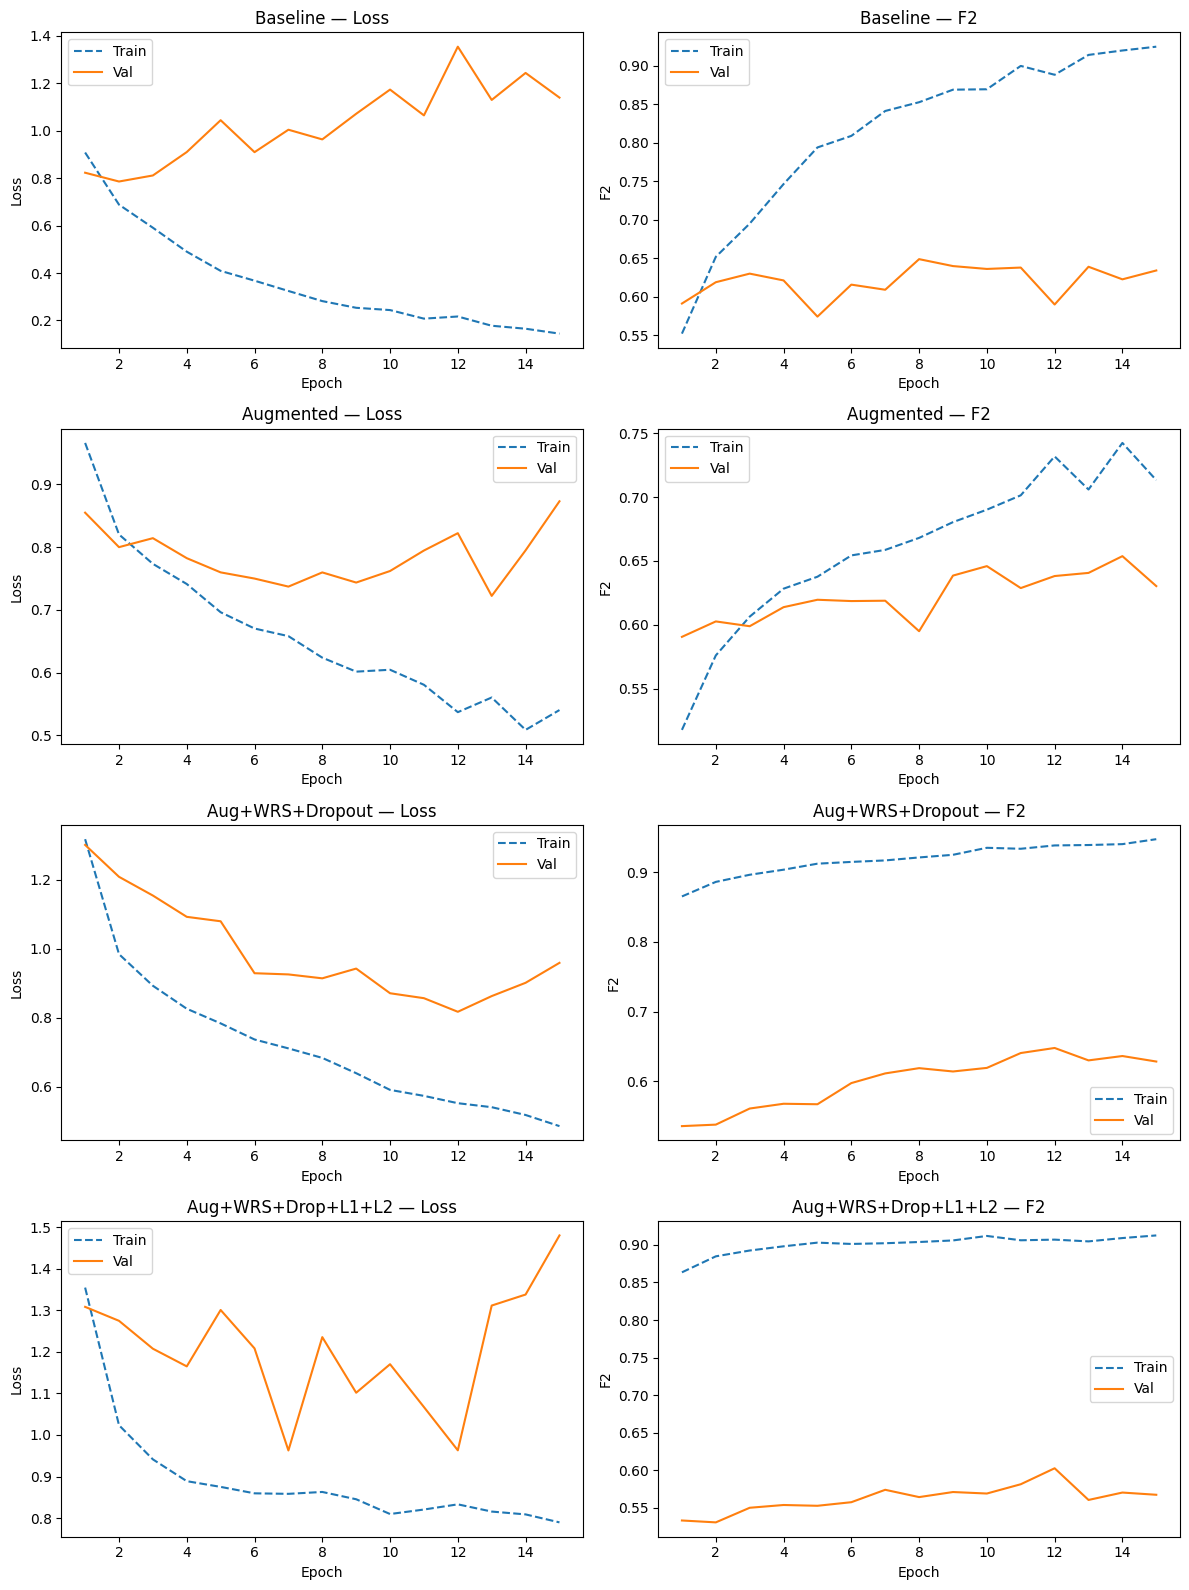

In [25]:
n_runs = len(all_results)
fig, axes = plt.subplots(n_runs, 2, figsize=(12, 4 * n_runs))

for row_idx, (run_label, result) in enumerate(all_results.items()):
    h      = result['history']
    epochs = range(1, len(h['train_loss']) + 1)

    ax_loss = axes[row_idx, 0]
    ax_loss.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax_loss.plot(epochs, h['val_loss'],   label='Val')
    ax_loss.set_title(f'{run_label} — Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()

    ax_f2 = axes[row_idx, 1]
    ax_f2.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax_f2.plot(epochs, h['val_f2'],   label='Val')
    ax_f2.set_title(f'{run_label} — F2')
    ax_f2.set_xlabel('Epoch')
    ax_f2.set_ylabel('F2')
    ax_f2.legend()

plt.tight_layout()
plt.show()

## Save Best Run

In [26]:
best_run_label = max(all_results, key=lambda k: all_results[k]['best_val_f2'])
best_cfg       = all_results[best_run_label]['cfg']
print(f'Best run: {best_run_label} (val F2 = {all_results[best_run_label]["best_val_f2"]:.4f})')

best_model = get_efficientnet(
    variant='b0',
    num_classes=1,
    unfreeze_last_n_blocks=3,
    dropout=best_cfg['dropout'],
).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in all_results[best_run_label]['best_state'].items()})

save_path = 'models/efficientnet_b0_aug_wrs_dropout_best.pth'
torch.save(best_model.state_dict(), save_path)
print(f'Saved to {save_path}')

Best run: Augmented (val F2 = 0.6537)
Saved to models/efficientnet_b0_aug_wrs_dropout_best.pth


## Test Set Evaluation — Best Run

In [27]:
best_model.eval()
best_threshold = all_results[best_run_label]['threshold']

all_labels = []
all_probs  = []
all_preds  = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = best_model(images)
        probs   = torch.sigmoid(outputs).squeeze(1)
        preds   = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print(f'Best run: {best_run_label} | Threshold: {best_threshold:.2f}')
print()
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, target_names=['Non-Melanoma', 'Melanoma'], digits=4))

Best run: Augmented | Threshold: 0.51

Confusion Matrix:
[[1048  292]
 [  30  141]]

              precision    recall  f1-score   support

Non-Melanoma     0.9722    0.7821    0.8668      1340
    Melanoma     0.3256    0.8246    0.4669       171

    accuracy                         0.7869      1511
   macro avg     0.6489    0.8033    0.6669      1511
weighted avg     0.8990    0.7869    0.8216      1511



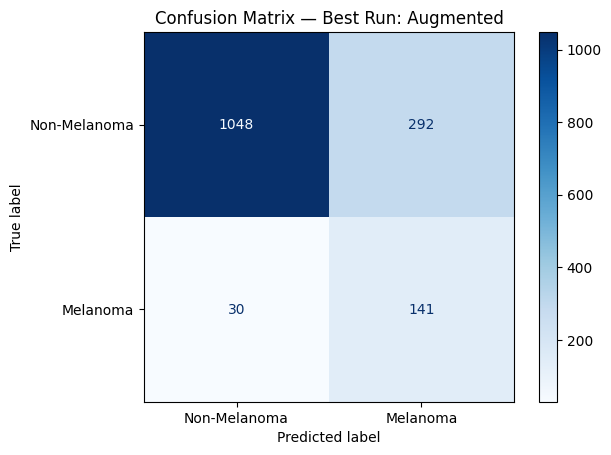

In [28]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — Best Run: {best_run_label}')
plt.show()